# Opik Metrics Explorer

Notebook for loading Opik traces and threads, selecting useful fields, and generating comparison plots for ChatDev benchmark runs.

Main outputs:
- Trace feedback score plots by condition, benchmark, and agent.
- Thread metric plots by condition and benchmark.
- Thread feedback score plots, including requirements coverage and implementation completeness.
- Spearman correlation heatmap for benchmark outcomes vs process metrics.


## 1. Environment


In [11]:
import os
os.environ["OPIK_API_KEY"] = "fvgscIEntSdxGOAxp6CLhjIVa"
os.environ["OPIK_WORKSPACE"] = "aasmagroup23"
os.environ["OPIK_PROJECT_NAME"] = "ChatDev-AASMA"

#!pip install opik pandas -q


## 2. Imports and Opik Client


In [12]:
from __future__ import annotations
from matplotlib import pyplot as plt

import os
from typing import Any, Iterable
import numpy as np

import pandas as pd

try:
    from opik import Opik
except Exception as exc:
    raise RuntimeError("The opik package is required in this environment.") from exc

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)


In [13]:
PROJECT_NAME = os.getenv('OPIK_PROJECT_NAME', 'ChatDev')
OPIK_HOST = os.getenv('OPIK_URL_OVERRIDE', 'https://www.comet.com/opik/api')
OPIK_WORKSPACE = os.getenv('OPIK_WORKSPACE') or os.getenv('OPIK_WORKSPACE_NAME')
OPIK_API_KEY = os.getenv('OPIK_API_KEY')

client = Opik(
    project_name=PROJECT_NAME,
    host=OPIK_HOST,
    workspace=OPIK_WORKSPACE,
    api_key=OPIK_API_KEY,
)

PROJECT_NAME


'ChatDev-AASMA'

## 3. Fetch Helpers


In [14]:
def flatten_dict(value: dict[str, Any], prefix: str = '', sep: str = '.') -> dict[str, Any]:
    items: dict[str, Any] = {}
    for key, item in value.items():
        new_key = f'{prefix}{sep}{key}' if prefix else key
        if isinstance(item, dict):
            items.update(flatten_dict(item, new_key, sep=sep))
        else:
            items[new_key] = item
    return items

def pick_fields(record: Any, fields: Iterable[str]) -> dict[str, Any]:
    data: dict[str, Any] = {}
    for field in fields:
        value = record
        for part in field.split('.'):
            if value is None:
                break
            if isinstance(value, dict):
                value = value.get(part)
            else:
                value = getattr(value, part, None)
        data[field] = value
    return data

def as_dict(record: Any) -> dict[str, Any]:
    if isinstance(record, dict):
        return record
    if hasattr(record, 'model_dump'):
        return record.model_dump()
    if hasattr(record, 'dict'):
        return record.dict()
    return {k: getattr(record, k) for k in dir(record) if not k.startswith('_')}

def fetch_traces(
    filter_string: str | None = None,
    max_results: int = 1000,
    truncate: bool = False,
    exclude: list[str] | None = None,
) -> pd.DataFrame:
    traces = client.search_traces(
        project_name=PROJECT_NAME,
        filter_string=filter_string,
        max_results=max_results,
        truncate=truncate,
        exclude=exclude,
    )
    rows = [as_dict(trace) for trace in traces]
    return pd.json_normalize(rows, sep='.') if rows else pd.DataFrame()

def fetch_threads(
    filter_string: str | None = None,
    max_results: int = 1000,
    truncate: bool = False,
) -> pd.DataFrame:
    threads = client.search_threads(
        project_name=PROJECT_NAME,
        filter_string=filter_string,
        max_results=max_results,
        truncate=truncate,
    )
    rows = [as_dict(thread) for thread in threads]
    return pd.json_normalize(rows, sep='.') if rows else pd.DataFrame()


## 4. Load Data and Define Runs


In [15]:
TRACE_COLUMNS = [
    'id', 'name', 'tags', 'thread_id',
    'metadata.node_id', 'metadata.sender_ids', 'feedback_scores',
    'span_count', 'duration', 'total_estimated_cost', 'usage.prompt_tokens', 'usage.total_tokens',
]

THREAD_COLUMNS = [
    'id', 'status', 'duration', 'number_of_messages',
    'created_at', 'last_updated_at', 'feedback_scores', 'tags',
    'total_estimated_cost', 'usage.total_tokens',
]

def select_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    keep = [col for col in columns if col in df.columns]
    return df.loc[:, keep].copy() if keep else df.copy()

def extract_feedback_scores(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, trace in df.iterrows():
        scores = trace.get('feedback_scores')
        if not isinstance(scores, list):
            continue
        for score in scores:
            if not isinstance(score, dict):
                continue
            rows.append({
                'trace_id': trace.get('id'),
                'thread_id': trace.get('thread_id'),
                'node_id': trace.get('metadata.node_id'),
                'score_name': score.get('name'),
                'score_value': score.get('value'),
                'score_reason': score.get('reason'),
            })
    scores_df = pd.DataFrame(rows)
    if not scores_df.empty:
        scores_df['score_value'] = pd.to_numeric(scores_df['score_value'], errors='coerce')
    return scores_df

# Fetch traces and threads.
traces_raw = fetch_traces(max_results=2000, truncate=False)
threads_raw = fetch_threads(max_results=2000, truncate=False)

trace_df = select_columns(traces_raw, TRACE_COLUMNS)
thread_df = select_columns(threads_raw, THREAD_COLUMNS)
feedback_df = extract_feedback_scores(trace_df)

# Run group mapping.
thread_groups = {
    'client_liaison_run_1': [
        'c629ba35-e4ba-4a1e-b72d-acd350e739d9',
        'ea708e64-6003-4e24-8690-71db753d13f8',
        '2297d6fc-6432-4686-9553-0d19b5ab3d97',
        '9f877593-8e80-4bbf-8179-caa1886cdfdc',
        'd72eda67-643a-4361-aa8e-839a6df93624'
    ],
    'client_liaison_run_2': [
        '738bbc70-f060-4324-ba4b-ef2047771333',
        '8318b44c-288f-4e9d-9599-dc6be3a9c64b',
        '8faf0163-7d38-437d-a84d-9e0974a2d542',
        'd53c91ba-38fb-4704-942e-ac17bf23909c',
        '64f20dae-a7f5-4927-824b-61198103a26e'
    ],
    'client_liaison_run_3': [
        'a404c68f-9395-4412-b4f4-022013abcbe8',
        '95db105e-6e92-4e41-b4fd-b73eba9887e7',
        '4c7a7b65-f852-461e-b2bf-2bdaff50c334',
        'a2a0dfcb-76e1-4de6-8ebc-4077d222bbaf',
        '2c858a77-419e-4931-a6c7-ab2c7fa4cd59'
    ],
    'client_liaison_run_4': [
        'ef06882a-2679-41a8-884b-f8974b0609c9',
        'facd7f24-2191-447a-89d2-545f38cdfe29',
        'ad6878bc-8697-41e6-802e-1d50a15066de',
        '7b7c55f7-7267-4b57-82d8-ee8b595fbd84',
        'ac80fc19-24c9-4942-a486-1fa061f2a176'
    ],

    'client_liaison_run_5': [
        'a3e186b3-2aac-4a26-9391-4e4c926f05ff',
        '050a6bdc-6c14-4b0e-a059-8a4d406558fd',
        '74f97aca-a3f9-4f23-b7b3-a8c1210becb6',
        '3d73e911-705c-481d-90e9-c49a23f6d3b3',
        'fbbc6921-ecaf-48e9-ba98-0c0582af10ae'
    ],

    'original_run_1': [
        'd4df6e7c-283e-425a-be5d-c62e6da57870',
        'd77d9d99-e64b-44b6-b949-d107c99f6403',
        '0f0ca6d8-cdf9-4e67-991d-20ed2a621166',
        '52df482c-3ec1-480f-8fd1-6f541c0bccfd',
        '94120fc0-a8e6-4894-a7e1-48c2833afc3e'
    ],
    'original_run_2': [
        '859e0bd9-a02e-4d94-97c7-83738fd26ce6',
        '77700587-8aa3-43f6-8100-24e834ba7b38',
        '8f8629df-7631-46d5-a636-173127fc7040',
        '9ce35d91-0e5b-4b29-ab11-04414d0e3a2c',
        '37af9b32-161c-4ac3-a452-67e78f53cb12'
    ],
    'original_run_3': [
        'fff549e8-1b39-4867-9926-b16a90059bb7',
        'fc94b9a0-9634-446f-9318-95f815363653',
        '951e5e66-3acc-42c7-b9c0-857bc3774789',
        '454e2149-8c00-40f7-ae31-2d0f51f276a4',
        'f1c7f810-4021-4898-a500-213ee03593d0'
    ],

    'original_run_4': [
        '999875b3-1945-441a-bcfa-387467c3fb52',
        '26a7fb92-1c9f-4c3e-b98f-2d764646b155',
        'd2ddc9de-5d62-4878-93c1-7a408a3c2431',
        '1e8fbc46-7e37-4270-8603-2742f9380ff2',
        '29a3b966-37b5-4536-a53c-df7ed5a8219b'
    ],
    'original_run_5': [
        'ff9e336e-a845-437f-8766-513de78951aa',
        'b184b195-2124-4f13-b5ad-c25669f95993',
        '8d53a2ce-2e13-44ec-bcf2-3e54315cd645',
        'b3b5f434-948a-42b0-b1b9-5255a804f6d6',
        'a338052a-4641-4f4d-a6e1-201a6f3d280e']
}

thread_to_group = {tid: group for group, tids in thread_groups.items() for tid in tids}
selected_threads = list(thread_to_group.keys())

trace_df_filtered = trace_df[trace_df['thread_id'].isin(selected_threads)].copy()
thread_df_filtered = thread_df[thread_df['id'].isin(selected_threads)].copy()

trace_df_filtered['run_group'] = trace_df_filtered['thread_id'].map(thread_to_group)


## 5. Trace Feedback Score Preparation


In [16]:
# Normalize score names; Opik contains case/style duplicates.
score_rename = {
    'Handoff Quality': 'handoff_quality',
    'Responsiveness': 'input_responsiveness',
    'Role Compliance': 'role_compliance',
    'score1': None, 'score 2': None, 'score 3': None,  # discard
}

feedback_clean = feedback_df.copy()
feedback_clean['score_name'] = feedback_clean['score_name'].map(
    lambda x: score_rename.get(x, x)
)
feedback_clean = feedback_clean[feedback_clean['score_name'].notna()]

METRICS = ['handoff_quality', 'input_responsiveness', 'role_compliance']
feedback_clean = feedback_clean[feedback_clean['score_name'].isin(METRICS)]

# Add benchmark tag and run_group via thread_id.
thread_to_group = {tid: grp for grp, tids in thread_groups.items() for tid in tids}

# Rebuild thread_id -> benchmark map from traces.
thread_to_benchmark = (
    traces_raw[['thread_id', 'tags']]
    .dropna(subset=['thread_id', 'tags'])
    .assign(tags=lambda df: df['tags'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    ))
    .drop_duplicates('thread_id')
    .set_index('thread_id')['tags']
    .to_dict()
)

feedback_clean['run_group'] = feedback_clean['thread_id'].map(thread_to_group)
feedback_clean['benchmark'] = feedback_clean['thread_id'].map(thread_to_benchmark)
feedback_clean['condition'] = feedback_clean['run_group'].apply(
    lambda x: 'Client Liaison' if isinstance(x, str) and x.startswith('client') else 'Original'
)
feedback_clean = feedback_clean.dropna(subset=['run_group', 'benchmark'])

BENCHMARKS = [
    'benchmark_task_api',
    'benchmark_csv_pipeline',
    'benchmark_chat_server',
    'benchmark_url_shortener',
    'benchmark_expense_tracker',
]
BENCH_LABELS = {
    'benchmark_task_api': 'Task API',
    'benchmark_csv_pipeline': 'CSV Pipeline',
    'benchmark_chat_server': 'Chat Server',
    'benchmark_url_shortener': 'URL Shortener',
    'benchmark_expense_tracker': 'Expense Tracker',
}
NODES_ORDER = ['Chief Executive Officer', 'Chief Technology Officer',
               'Code Reviewer', 'Programmer', 'Tester']
COLORS = {'Client Liaison': '#2196F3', 'Original': '#FF5722'}


## 6. Trace Feedback Score Plots


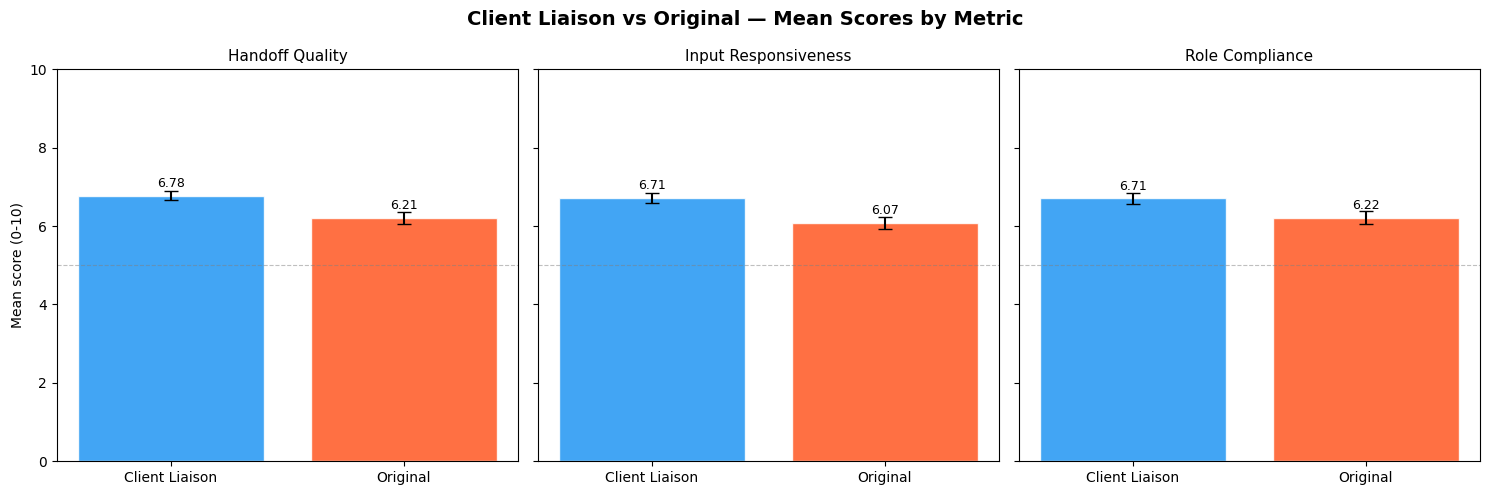

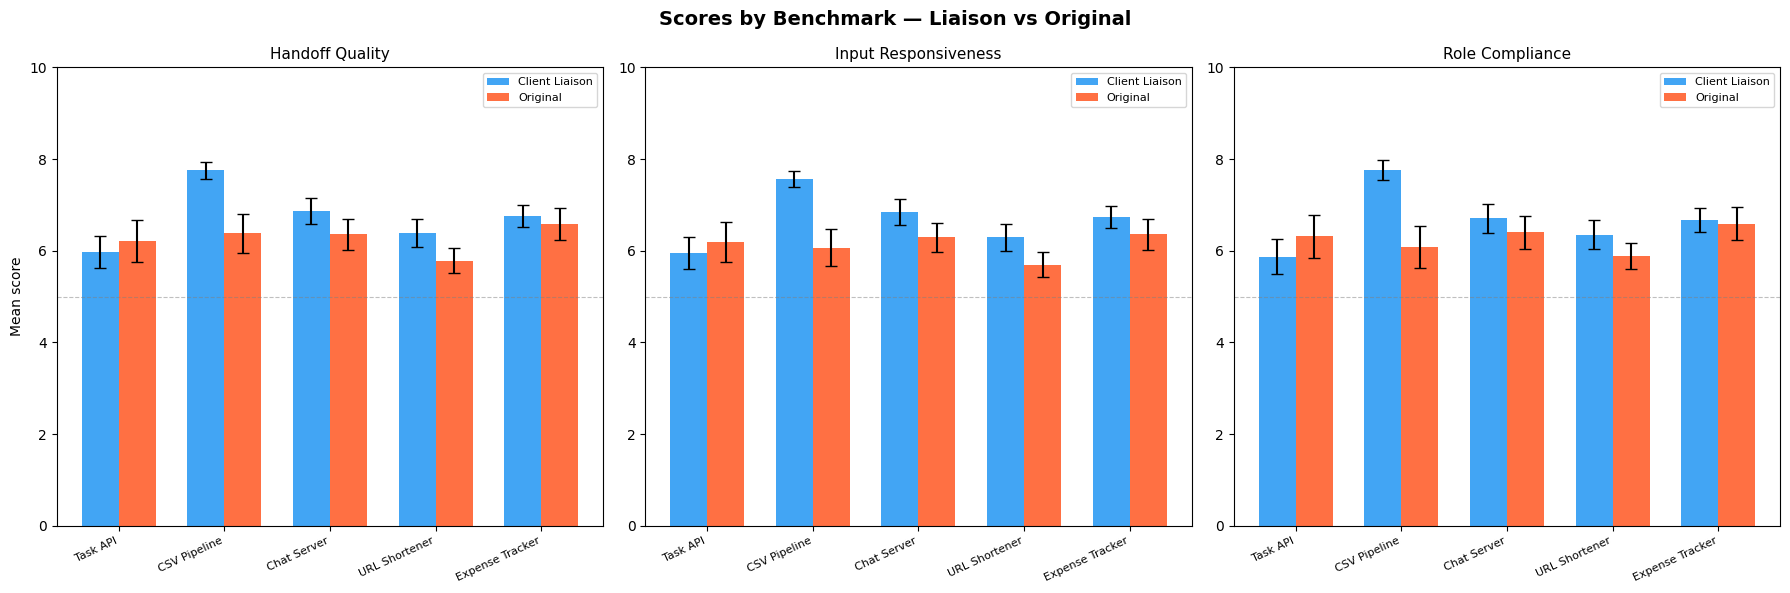

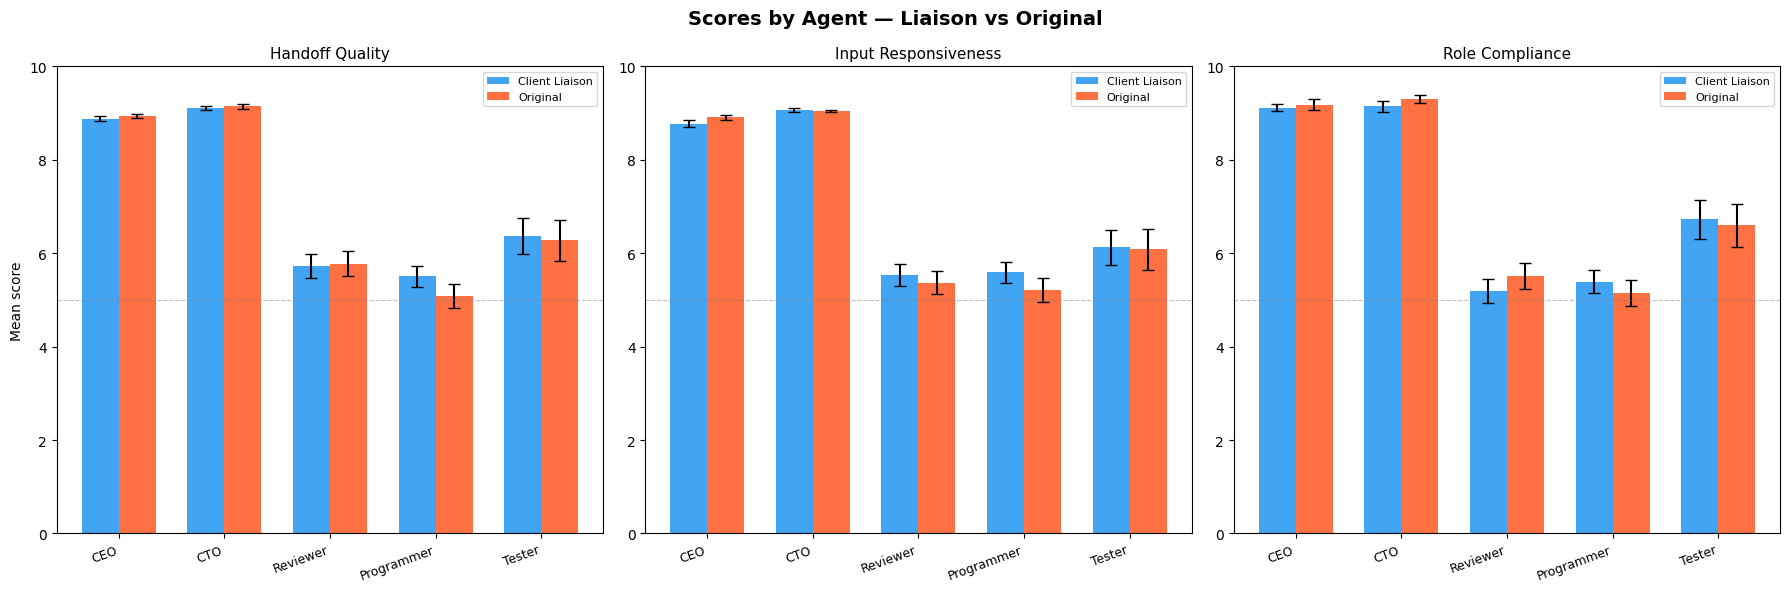

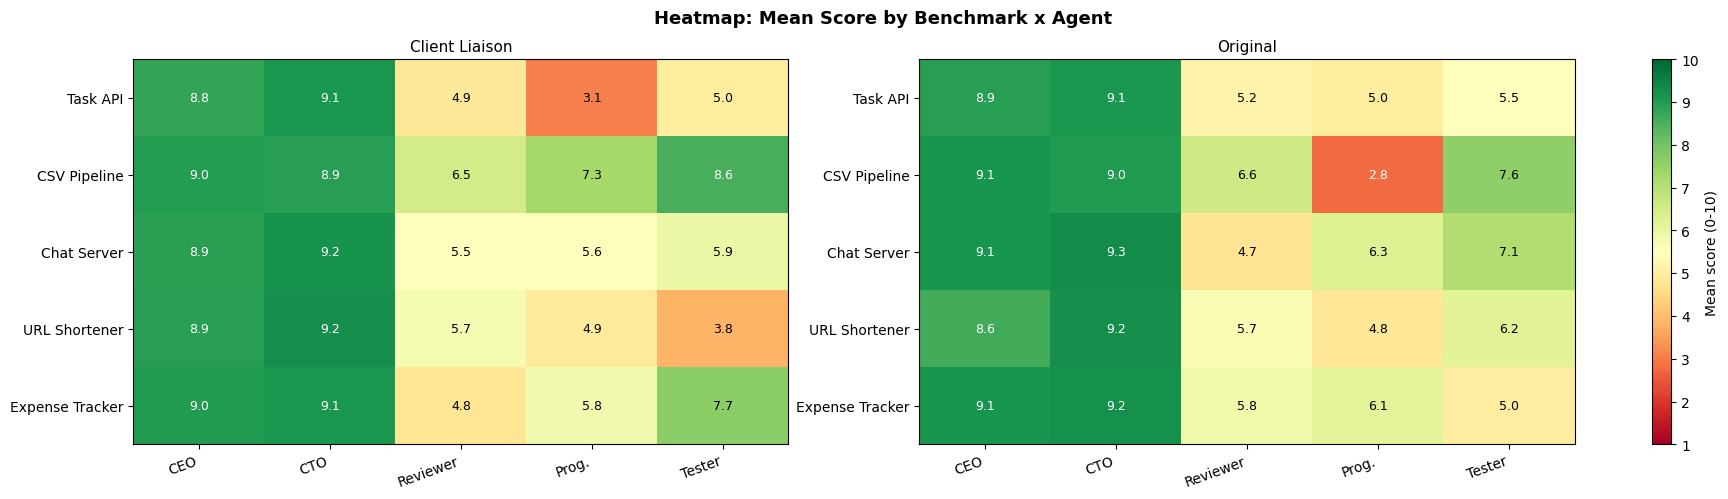

In [17]:
# ── 2. Plot 1: Liaison vs Original — mean scores by metric ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Client Liaison vs Original — Mean Scores by Metric', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, METRICS):
    grp = (
        feedback_clean[feedback_clean['score_name'] == metric]
        .groupby('condition')['score_value']
        .agg(['mean', 'sem'])
        .reindex(['Client Liaison', 'Original'])
    )
    bars = ax.bar(grp.index, grp['mean'], yerr=grp['sem'],
                  color=[COLORS[c] for c in grp.index],
                  capsize=5, alpha=0.85, edgecolor='white')
    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Mean score (0-10)' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{row["mean"]:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('scores_liaison_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Plot 2: Scores by benchmark (Liaison vs Original) ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scores by Benchmark — Liaison vs Original', fontsize=14, fontweight='bold')

x = np.arange(len(BENCHMARKS))
width = 0.35

for ax, metric in zip(axes, METRICS):
    vals = {}
    errs = {}
    for cond in ['Client Liaison', 'Original']:
        sub = feedback_clean[
            (feedback_clean['score_name'] == metric) &
            (feedback_clean['condition'] == cond)
        ]
        means = [sub[sub['benchmark'] == b]['score_value'].mean() for b in BENCHMARKS]
        sems  = [sub[sub['benchmark'] == b]['score_value'].sem()  for b in BENCHMARKS]
        vals[cond] = means
        errs[cond] = sems

    ax.bar(x - width/2, vals['Client Liaison'], width, yerr=errs['Client Liaison'],
           label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
    ax.bar(x + width/2, vals['Original'],       width, yerr=errs['Original'],
           label='Original',       color=COLORS['Original'],       capsize=4, alpha=0.85)

    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([BENCH_LABELS[b] for b in BENCHMARKS], rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Mean score' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scores_by_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Plot 3: Scores by agent (node_id) ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scores by Agent — Liaison vs Original', fontsize=14, fontweight='bold')

nodes_present = [n for n in NODES_ORDER if n in feedback_clean['node_id'].unique()]
x = np.arange(len(nodes_present))

for ax, metric in zip(axes, METRICS):
    vals = {}
    errs = {}
    for cond in ['Client Liaison', 'Original']:
        sub = feedback_clean[
            (feedback_clean['score_name'] == metric) &
            (feedback_clean['condition'] == cond)
        ]
        means = [sub[sub['node_id'] == n]['score_value'].mean() for n in nodes_present]
        sems  = [sub[sub['node_id'] == n]['score_value'].sem()  for n in nodes_present]
        vals[cond] = means
        errs[cond] = sems

    ax.bar(x - width/2, vals['Client Liaison'], width, yerr=errs['Client Liaison'],
           label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
    ax.bar(x + width/2, vals['Original'],       width, yerr=errs['Original'],
           label='Original',       color=COLORS['Original'],       capsize=4, alpha=0.85)

    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_xticks(x)
    short = {'Chief Executive Officer': 'CEO', 'Chief Technology Officer': 'CTO',
             'Code Reviewer': 'Reviewer', 'Programmer': 'Programmer', 'Tester': 'Tester'}
    ax.set_xticklabels([short.get(n, n) for n in nodes_present], rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Mean score' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scores_by_agent.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Plot 4: Heatmap — mean score by benchmark x agent ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Heatmap: Mean Score by Benchmark x Agent', fontsize=13, fontweight='bold')

for ax, cond in zip(axes, ['Client Liaison', 'Original']):
    sub = feedback_clean[feedback_clean['condition'] == cond]
    pivot = sub.groupby(['benchmark', 'node_id'])['score_value'].mean().unstack(fill_value=np.nan)
    pivot = pivot.reindex(index=BENCHMARKS, columns=nodes_present)
    pivot.index = [BENCH_LABELS[b] for b in BENCHMARKS]

    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=1, vmax=10, aspect='auto')
    ax.set_xticks(range(len(nodes_present)))
    short = {'Chief Executive Officer': 'CEO', 'Chief Technology Officer': 'CTO',
             'Code Reviewer': 'Reviewer', 'Programmer': 'Prog.', 'Tester': 'Tester'}
    ax.set_xticklabels([short.get(n, n) for n in nodes_present], rotation=20, ha='right')
    ax.set_yticks(range(len(BENCHMARKS)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(cond, fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                        color='black' if 3 < val < 8 else 'white')

plt.colorbar(im, ax=axes, fraction=0.02, label='Mean score (0-10)')
plt.savefig('heatmap_benchmark_agent.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Thread Metrics, Thread Feedback, and Correlations


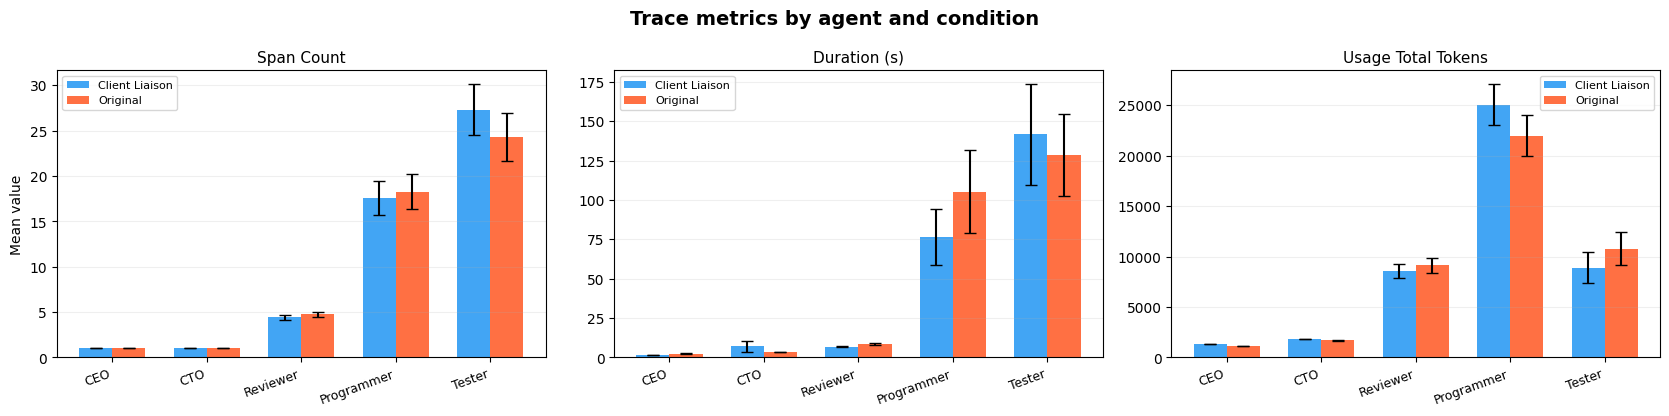

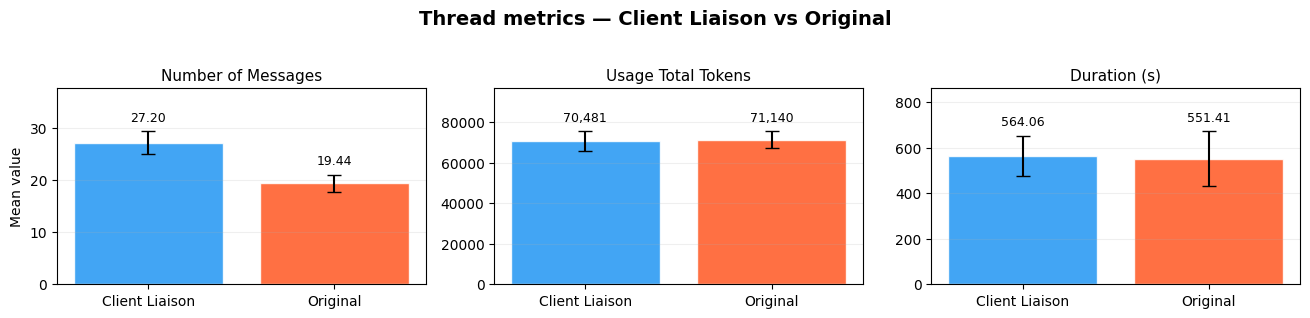

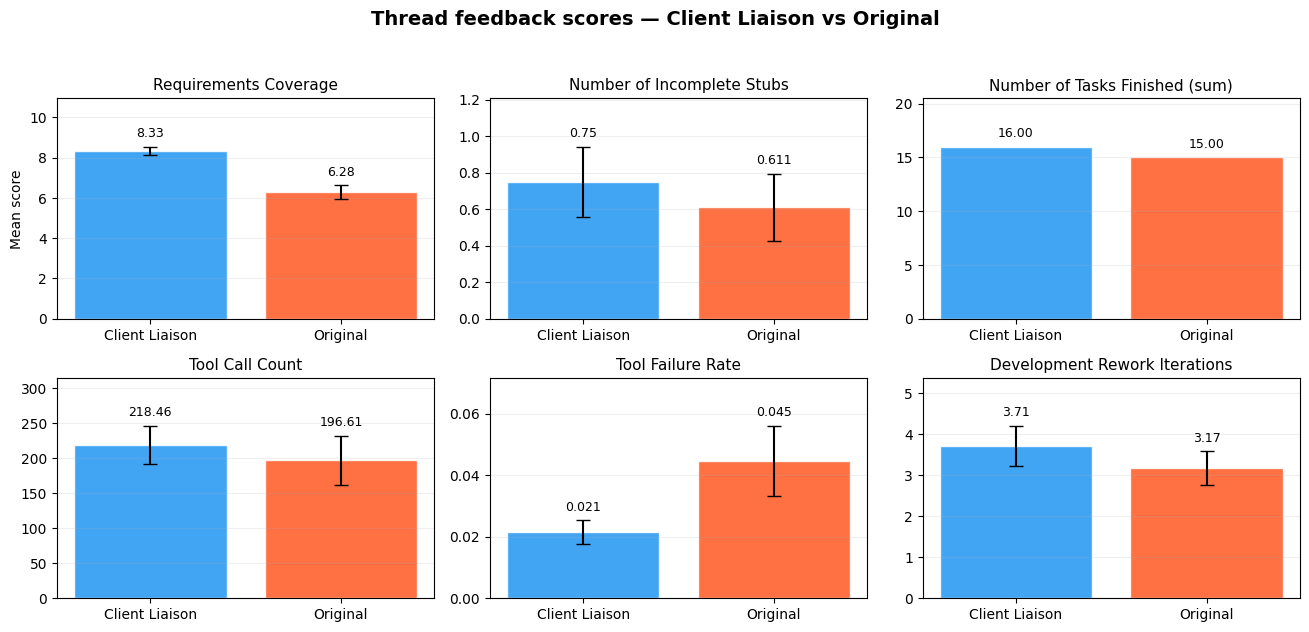

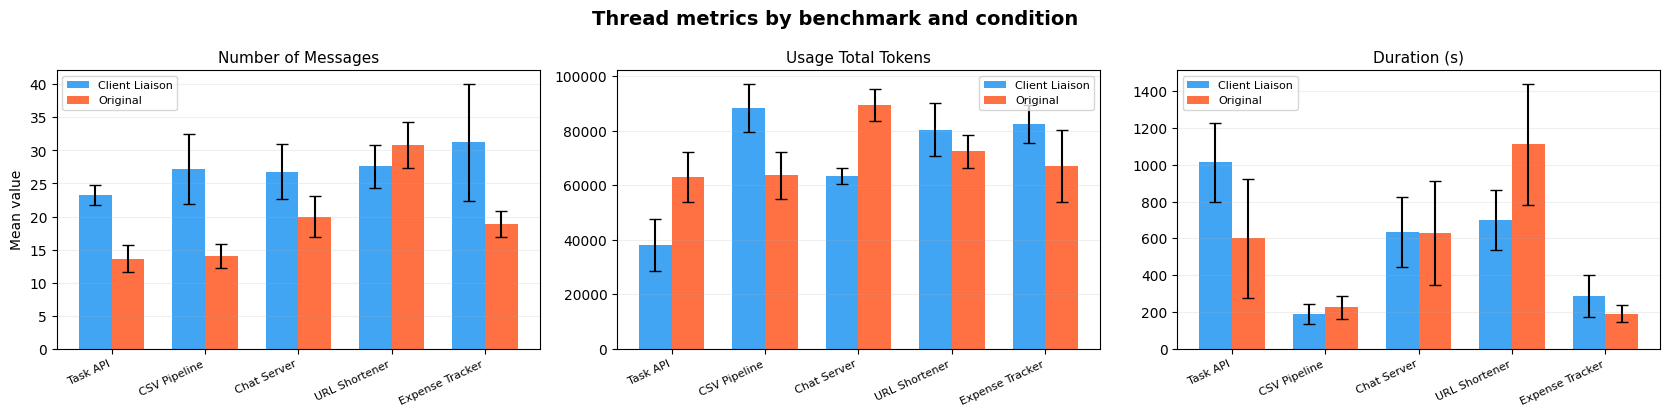

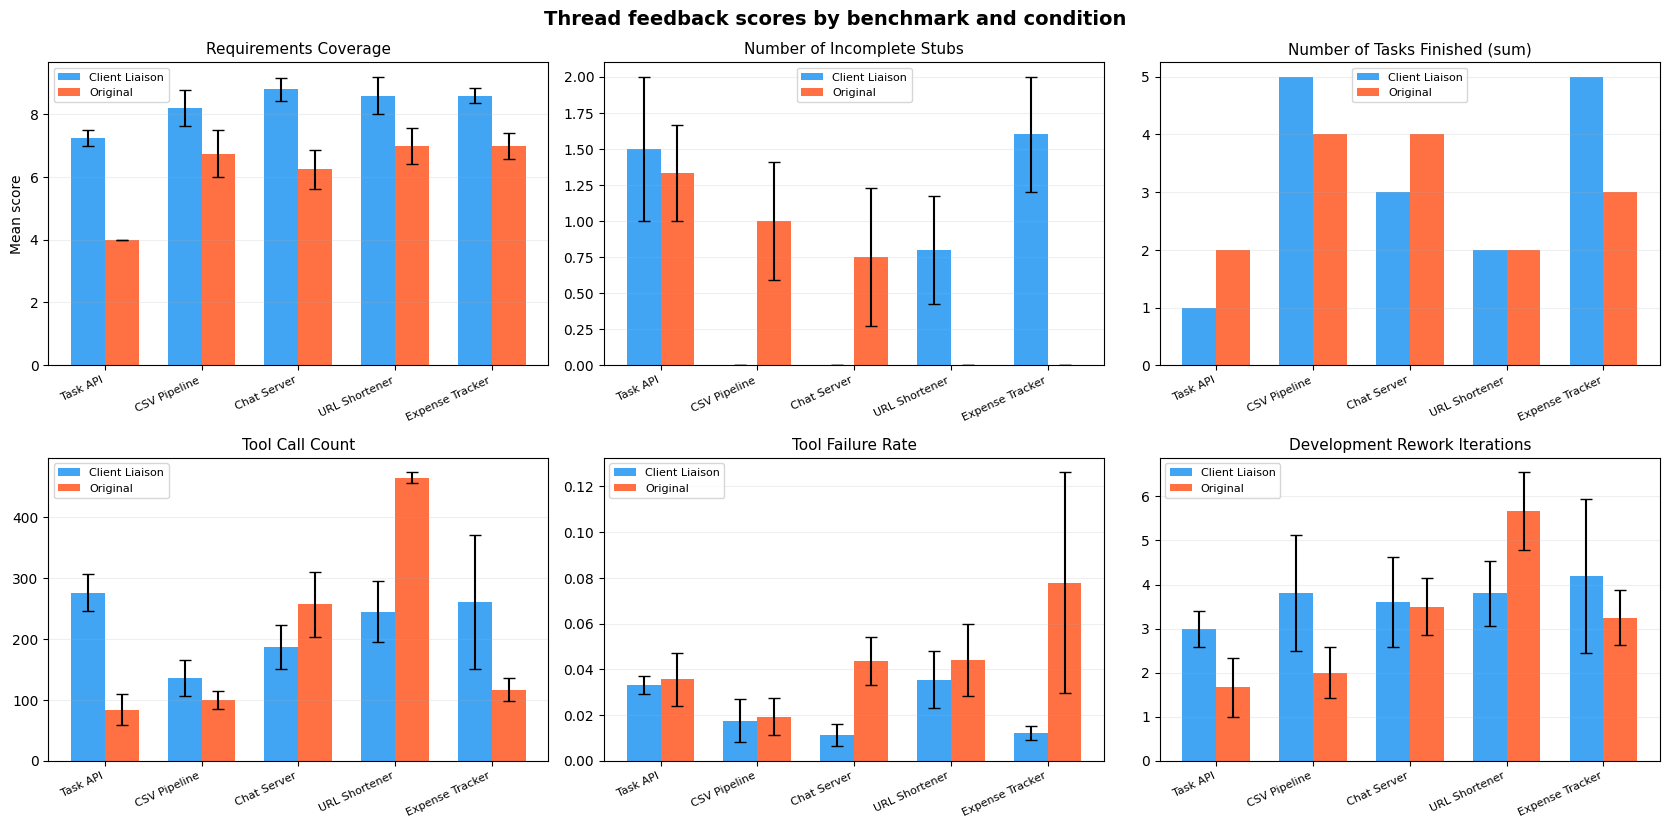

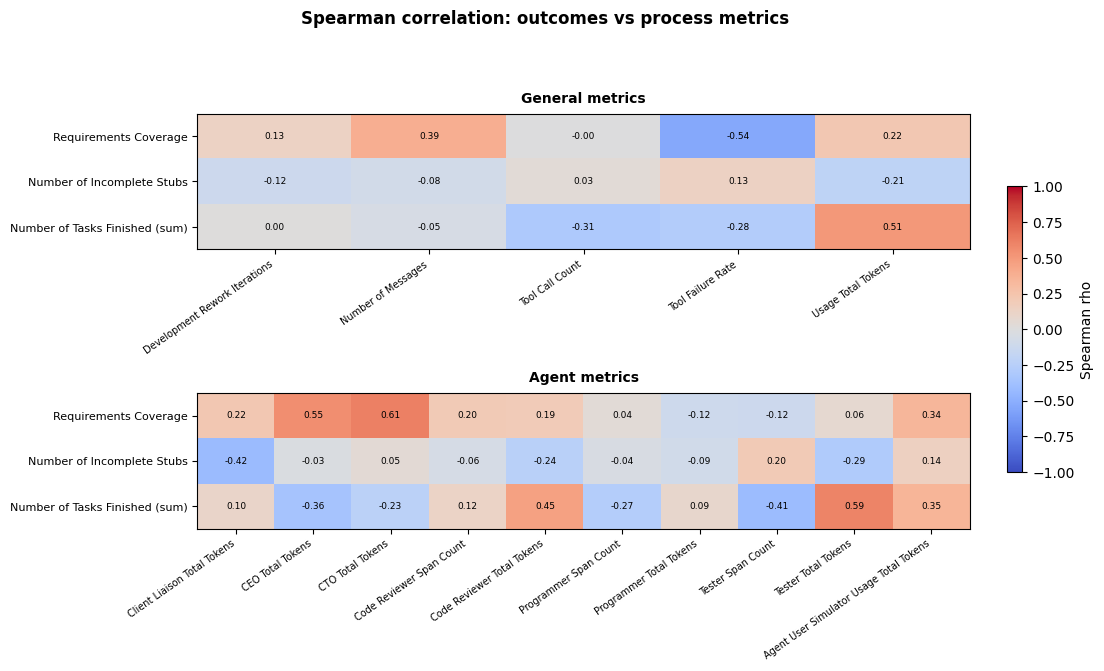

6 charts generated and saved.


In [18]:
# ── 6. Additional metric plots: traces, threads, and thread feedback ─────

TRACE_METRICS = ['span_count', 'duration', 'usage.total_tokens']
THREAD_METRICS = ['number_of_messages', 'usage.total_tokens', 'duration']
THREAD_FEEDBACK_RENAME = {
    'thread_task_finished': 'task_finished',
    'thread_error_count': 'error_count',
    'thread_warning_count': 'warning_count',
    'thread_tool_call_count': 'tool_call_count',
    'thread_tool_failure_rate': 'tool_failure_rate',
    'thread_cycle_0_iterations': 'development_rework_iterations',
}
THREAD_FEEDBACK_METRICS = [
    'benchmark_requirements_rating',
    'benchmark_completeness',
    'task_finished',
    'tool_call_count',
    'tool_failure_rate',
    'development_rework_iterations',
]

def _condition_from_thread_id(thread_id: Any) -> str | None:
    group = thread_to_group.get(thread_id)
    if isinstance(group, str) and group.startswith('client'):
        return 'Client Liaison'
    if isinstance(group, str) and group.startswith('original'):
        return 'Original'
    return None

def _benchmark_from_thread_id(thread_id: Any, tags: Any = None) -> str | None:
    benchmark = thread_to_benchmark.get(thread_id)
    if isinstance(benchmark, str):
        return benchmark
    if isinstance(tags, list) and tags:
        return str(tags[0])
    if isinstance(tags, str):
        return tags
    return None

def build_metric_long_df(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    working = df.copy()
    id_col = 'thread_id' if 'thread_id' in working.columns else 'id'
    working['thread_id'] = working[id_col]
    working['benchmark'] = working.apply(lambda row: _benchmark_from_thread_id(row['thread_id'], row.get('tags')), axis=1)
    working['condition'] = working['thread_id'].map(_condition_from_thread_id)
    if 'metadata.node_id' in working.columns:
        working['node_id'] = working['metadata.node_id']
    elif 'node_id' not in working.columns:
        working['node_id'] = None
    rows = []
    for metric in metrics:
        if metric not in working.columns:
            continue
        sub = working[['thread_id', 'benchmark', 'condition', 'node_id', metric]].copy()
        sub = sub.rename(columns={metric: 'value'})
        sub['metric'] = metric
        sub['value'] = pd.to_numeric(sub['value'], errors='coerce')
        if metric == 'duration':
            sub['value'] = sub['value'] / 1000.0
        rows.append(sub)
    if not rows:
        return pd.DataFrame(columns=['thread_id', 'benchmark', 'condition', 'node_id', 'metric', 'value'])
    return pd.concat(rows, ignore_index=True).dropna(subset=['benchmark', 'condition'])

def build_feedback_long_df(df: pd.DataFrame, wanted_metrics: list[str]) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        scores = row.get('feedback_scores')
        if not isinstance(scores, list):
            continue
        thread_id = row.get('thread_id', row.get('id'))
        benchmark = _benchmark_from_thread_id(thread_id, row.get('tags'))
        condition = _condition_from_thread_id(thread_id)
        for score in scores:
            if not isinstance(score, dict):
                continue
            raw_name = str(score.get('name', ''))
            normalized = THREAD_FEEDBACK_RENAME.get(raw_name, raw_name)
            if normalized.startswith('thread_'):
                normalized = normalized[len('thread_'):]
            if normalized not in wanted_metrics:
                continue
            rows.append({
                'thread_id': thread_id,
                'benchmark': benchmark,
                'condition': condition,
                'metric': normalized,
                'value': pd.to_numeric(score.get('value'), errors='coerce'),
            })
    if not rows:
        return pd.DataFrame(columns=['thread_id', 'benchmark', 'condition', 'metric', 'value'])
    return pd.DataFrame(rows).dropna(subset=['benchmark', 'condition'])

def _aggregate_metric_values(series: pd.Series, metric: str) -> tuple[float, float]:
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return np.nan, np.nan
    if metric == 'task_finished':
        return values.sum(), np.nan
    return values.mean(), values.sem()

def plot_metric_grid(df: pd.DataFrame, metrics: list[str], title: str, filename: str, ylabel: str) -> None:
    if df.empty:
        print(f'No data available for {title}')
        return
    ncols = min(3, len(metrics)) if len(metrics) > 1 else 1
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.2 * nrows), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()
    x = np.arange(len(BENCHMARKS))
    width = 0.35
    for ax, metric in zip(axes_flat, metrics):
        sub = df[df['metric'] == metric]
        vals = {}
        errs = {}
        for cond in ['Client Liaison', 'Original']:
            cond_df = sub[sub['condition'] == cond]
            stats = [_aggregate_metric_values(cond_df[cond_df['benchmark'] == benchmark]['value'], metric) for benchmark in BENCHMARKS]
            vals[cond] = [value for value, _ in stats]
            errs[cond] = [err for _, err in stats]
        yerr_liaison = None if metric == 'task_finished' else errs['Client Liaison']
        yerr_original = None if metric == 'task_finished' else errs['Original']
        ax.bar(x - width/2, vals['Client Liaison'], width, yerr=yerr_liaison, label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
        ax.bar(x + width/2, vals['Original'], width, yerr=yerr_original, label='Original', color=COLORS['Original'], capsize=4, alpha=0.85)
        ax.set_title(METRIC_LABELS.get(metric, metric.replace('_', ' ').title()), fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels([BENCH_LABELS[b] for b in BENCHMARKS], rotation=25, ha='right', fontsize=8)
        ax.set_ylabel(ylabel if ax == axes_flat[0] else '')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.2)
    for ax in axes_flat[len(metrics):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def plot_trace_metric_grid_by_agent(df: pd.DataFrame, metrics: list[str], title: str, filename: str) -> None:
    if df.empty or 'node_id' not in df.columns:
        print(f'No agent-level trace data available for {title}')
        return
    nodes_present = [node for node in NODES_ORDER if node in df['node_id'].dropna().unique()]
    if not nodes_present:
        print(f'No mapped agents available for {title}')
        return
    ncols = min(3, len(metrics)) if len(metrics) > 1 else 1
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.2 * nrows), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()
    x = np.arange(len(nodes_present))
    width = 0.35
    short = {'Chief Executive Officer': 'CEO', 'Chief Technology Officer': 'CTO', 'Code Reviewer': 'Reviewer', 'Programmer': 'Programmer', 'Tester': 'Tester'}
    for ax, metric in zip(axes_flat, metrics):
        sub = df[df['metric'] == metric]
        vals = {}
        errs = {}
        for cond in ['Client Liaison', 'Original']:
            cond_df = sub[sub['condition'] == cond]
            vals[cond] = [cond_df[cond_df['node_id'] == node]['value'].mean() for node in nodes_present]
            errs[cond] = [cond_df[cond_df['node_id'] == node]['value'].sem() for node in nodes_present]
        ax.bar(x - width/2, vals['Client Liaison'], width, yerr=errs['Client Liaison'], label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
        ax.bar(x + width/2, vals['Original'], width, yerr=errs['Original'], label='Original', color=COLORS['Original'], capsize=4, alpha=0.85)
        ax.set_title(METRIC_LABELS.get(metric, metric.replace('_', ' ').title()), fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels([short.get(node, node) for node in nodes_present], rotation=20, ha='right', fontsize=9)
        ax.set_ylabel('Mean value' if ax == axes_flat[0] else '')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.2)
    for ax in axes_flat[len(metrics):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def plot_overall_metric_scores_by_condition(df: pd.DataFrame, metrics: list[str], title: str, filename: str, ylabel: str) -> None:
    if df.empty:
        print(f'No data available for {title}')
        return
    available_metrics = [metric for metric in metrics if metric in df['metric'].dropna().unique()]
    if not available_metrics:
        print(f'No requested metrics available for {title}')
        return

    ncols = 2 if len(available_metrics) == 4 else min(3, len(available_metrics))
    nrows = int(np.ceil(len(available_metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.2 * nrows), squeeze=False, sharey=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()

    def fmt_value(value: float) -> str:
        if pd.isna(value):
            return ''
        if abs(value) >= 1000:
            return f'{value:,.0f}'
        if abs(value) < 1:
            return f'{value:.3f}'.rstrip('0').rstrip('.')
        return f'{value:.2f}'

    for ax, metric in zip(axes_flat, available_metrics):
        metric_df = df[df['metric'] == metric]
        if metric == 'task_finished':
            grp = metric_df.groupby('condition')['value'].sum().to_frame('mean')
            grp['sem'] = np.nan
        else:
            grp = metric_df.groupby('condition')['value'].agg(['mean', 'sem'])
        grp = grp.reindex(['Client Liaison', 'Original'])
        bars = ax.bar(
            grp.index,
            grp['mean'],
            yerr=None if metric == 'task_finished' else grp['sem'],
            color=[COLORS.get(condition, '#777777') for condition in grp.index],
            capsize=5,
            alpha=0.85,
            edgecolor='white',
        )
        sem = grp['sem'].fillna(0)
        max_height = (grp['mean'] + sem).max()
        if pd.notna(max_height):
            ax.set_ylim(0, max_height * 1.28 if max_height > 0 else 1)
        ax.set_title(METRIC_LABELS.get(metric, metric.replace('_', ' ').title()), fontsize=11)
        ax.set_ylabel(ylabel if ax == axes_flat[0] else '')
        ax.grid(axis='y', alpha=0.2)
        for bar, (_, row) in zip(bars, grp.iterrows()):
            if pd.notna(row['mean']):
                label_y = row['mean'] + (0 if pd.isna(row['sem']) else row['sem'])
                ax.annotate(
                    fmt_value(row['mean']),
                    xy=(bar.get_x() + bar.get_width() / 2, label_y),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    clip_on=False,
                )

    for ax in axes_flat[len(available_metrics):]:
        ax.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def _safe_metric_name(value: Any) -> str:
    return str(value).replace(' ', '_').replace('.', '_').replace('/', '_').lower()

def build_correlation_frame(
    trace_metric_df: pd.DataFrame,
    thread_metric_df: pd.DataFrame,
    thread_feedback_df: pd.DataFrame,
) -> pd.DataFrame:
    pieces = []

    if not thread_metric_df.empty:
        thread_wide = (
            thread_metric_df
            .pivot_table(index=['thread_id', 'benchmark', 'condition'], columns='metric', values='value', aggfunc='mean')
            .reset_index()
        )
        pieces.append(thread_wide)

    if not thread_feedback_df.empty:
        feedback_wide = (
            thread_feedback_df
            .pivot_table(index=['thread_id', 'benchmark', 'condition'], columns='metric', values='value', aggfunc='mean')
            .reset_index()
        )
        pieces.append(feedback_wide)

    if not trace_metric_df.empty and 'node_id' in trace_metric_df.columns:
        trace_work = trace_metric_df.dropna(subset=['node_id']).copy()
        trace_work['agent_metric'] = trace_work.apply(
            lambda row: f"agent_{_safe_metric_name(row['node_id'])}_{_safe_metric_name(row['metric'])}",
            axis=1,
        )
        trace_wide = (
            trace_work
            .pivot_table(index=['thread_id', 'benchmark', 'condition'], columns='agent_metric', values='value', aggfunc='sum')
            .reset_index()
        )
        pieces.append(trace_wide)

    if not pieces:
        return pd.DataFrame()

    corr_df = pieces[0]
    for piece in pieces[1:]:
        corr_df = corr_df.merge(piece, on=['thread_id', 'benchmark', 'condition'], how='outer')
    return corr_df

def plot_outcome_correlation_heatmap(corr_df: pd.DataFrame, filename: str) -> None:
    if corr_df.empty:
        print('Skipping correlation heatmap: no correlation data available.')
        return

    outcomes = [
        'benchmark_requirements_rating',
        'benchmark_completeness',
        'task_finished',
    ]
    outcomes = [metric for metric in outcomes if metric in corr_df.columns]
    numeric_df = corr_df.drop(columns=['thread_id', 'benchmark', 'condition'], errors='ignore').apply(pd.to_numeric, errors='coerce')
    numeric_df = numeric_df.loc[:, numeric_df.notna().sum() >= 2]
    numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]
    outcomes = [metric for metric in outcomes if metric in numeric_df.columns]
    features = [metric for metric in numeric_df.columns if metric not in outcomes]
    excluded_fragments = ['cost', 'duration', 'total_estimated_cost']
    features = [
        metric for metric in features
        if not any(fragment in metric.lower() for fragment in excluded_fragments)
    ]

    agent_group_prefixes = {
        'agent_chief_executive_officer_': 'CEO',
        'agent_chief_technology_officer_': 'CTO',
        'agent_client_liaison_': 'Client Liaison',
        'agent_code_reviewer_': 'Code Reviewer',
        'agent_programmer_': 'Programmer',
        'agent_tester_': 'Tester',
        'agent_user_simulator_': 'User Simulator',
    }

    def feature_group(metric: str) -> str:
        for prefix, label in agent_group_prefixes.items():
            if metric.startswith(prefix):
                return label
        return 'General'

    group_order = ['General', 'Client Liaison', 'CEO', 'CTO', 'Code Reviewer', 'Programmer', 'Tester', 'User Simulator']
    features = sorted(
        features,
        key=lambda metric: (
            group_order.index(feature_group(metric)) if feature_group(metric) in group_order else len(group_order),
            METRIC_LABELS.get(metric, metric.replace('_', ' ').title()),
        ),
    )

    if not outcomes or not features:
        print('Skipping correlation heatmap: need variable outcomes and feature metrics.')
        return

    corr = numeric_df[outcomes + features].corr(method='spearman').loc[outcomes, features]
    general_cols = [metric for metric in corr.columns if feature_group(metric) == 'General']
    agent_cols = [metric for metric in corr.columns if feature_group(metric) != 'General']
    panels = [("General metrics", general_cols), ("Agent metrics", agent_cols)]
    panels = [(title, cols) for title, cols in panels if cols]

    if not panels:
        print('Skipping correlation heatmap: no feature groups available after filtering.')
        return

    max_cols = max(len(cols) for _, cols in panels)
    fig_width = max(11, 0.55 * max_cols + 5)
    fig_height = max(6.2, 2.55 * len(panels) + 1.7)
    fig, axes = plt.subplots(len(panels), 1, figsize=(fig_width, fig_height), squeeze=False)
    axes_flat = axes.flatten()
    readable_rows = [METRIC_LABELS.get(metric, metric.replace('_', ' ').title()) for metric in corr.index]
    im = None

    for ax, (panel_title, cols) in zip(axes_flat, panels):
        panel_corr = corr[cols]
        readable_cols = [METRIC_LABELS.get(metric, metric.replace('_', ' ').title()) for metric in panel_corr.columns]
        im = ax.imshow(panel_corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
        ax.set_title(panel_title, fontsize=10, fontweight='bold', pad=8)
        ax.set_xticks(np.arange(len(readable_cols)))
        ax.set_xticklabels(readable_cols, rotation=35, ha='right', fontsize=7)
        ax.set_yticks(np.arange(len(readable_rows)))
        ax.set_yticklabels(readable_rows, fontsize=8)
        for i in range(panel_corr.shape[0]):
            for j in range(panel_corr.shape[1]):
                value = panel_corr.values[i, j]
                if not np.isnan(value):
                    ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=6.5, color='black')

    for ax in axes_flat[len(panels):]:
        ax.axis('off')

    fig.suptitle('Spearman correlation: outcomes vs process metrics', fontsize=12, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 0.9, 0.93])
    if im is not None:
        cbar_ax = fig.add_axes([0.92, 0.3, 0.014, 0.42])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Spearman rho')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

METRIC_LABELS = {
    'span_count': 'Span Count',
    'duration': 'Duration (s)',
    'usage.total_tokens': 'Usage Total Tokens',
    'number_of_messages': 'Number of Messages',
    'benchmark_requirements_rating': 'Requirements Coverage',
    'benchmark_completeness': 'Number of Incomplete Stubs',
    'task_finished': 'Number of Tasks Finished (sum)',
    'tool_call_count': 'Tool Call Count',
    'tool_failure_rate': 'Tool Failure Rate',
    'development_rework_iterations': 'Development Rework Iterations',
    'agent_chief_executive_officer_span_count': 'CEO Span Count',
    'agent_chief_executive_officer_usage_total_tokens': 'CEO Total Tokens',
    'agent_chief_technology_officer_span_count': 'CTO Span Count',
    'agent_chief_technology_officer_usage_total_tokens': 'CTO Total Tokens',
    'agent_client_liaison_span_count': 'Client Liaison Span Count',
    'agent_client_liaison_duration': 'Client Liaison Duration',
    'agent_client_liaison_usage_total_tokens': 'Client Liaison Total Tokens',
    'agent_programmer_span_count': 'Programmer Span Count',
    'agent_programmer_duration': 'Programmer Duration',
    'agent_programmer_usage_total_tokens': 'Programmer Total Tokens',
    'agent_code_reviewer_span_count': 'Code Reviewer Span Count',
    'agent_code_reviewer_duration': 'Code Reviewer Duration',
    'agent_code_reviewer_usage_total_tokens': 'Code Reviewer Total Tokens',
    'agent_tester_span_count': 'Tester Span Count',
    'agent_tester_duration': 'Tester Duration',
    'agent_tester_usage_total_tokens': 'Tester Total Tokens',
}

trace_metric_df = build_metric_long_df(trace_df_filtered, TRACE_METRICS)
thread_metric_df = build_metric_long_df(thread_df_filtered, THREAD_METRICS)
thread_feedback_df = build_feedback_long_df(thread_df_filtered, THREAD_FEEDBACK_METRICS)

plot_trace_metric_grid_by_agent(trace_metric_df, TRACE_METRICS, 'Trace metrics by agent and condition', 'trace_metrics_by_agent.png')
plot_overall_metric_scores_by_condition(thread_metric_df, THREAD_METRICS, 'Thread metrics — Client Liaison vs Original', 'thread_metrics_liaison_vs_original.png', 'Mean value')
plot_overall_metric_scores_by_condition(thread_feedback_df, THREAD_FEEDBACK_METRICS, 'Thread feedback scores — Client Liaison vs Original', 'thread_feedback_liaison_vs_original.png', 'Mean score')
plot_metric_grid(thread_metric_df, THREAD_METRICS, 'Thread metrics by benchmark and condition', 'thread_metrics_by_benchmark.png', 'Mean value')
plot_metric_grid(thread_feedback_df, THREAD_FEEDBACK_METRICS, 'Thread feedback scores by benchmark and condition', 'thread_feedback_scores_by_benchmark.png', 'Mean score')
correlation_df = build_correlation_frame(trace_metric_df, thread_metric_df, thread_feedback_df)
plot_outcome_correlation_heatmap(correlation_df, 'outcome_correlation_heatmap.png')

print("6 charts generated and saved.")


## 8. Benchmark Result Failure Analysis


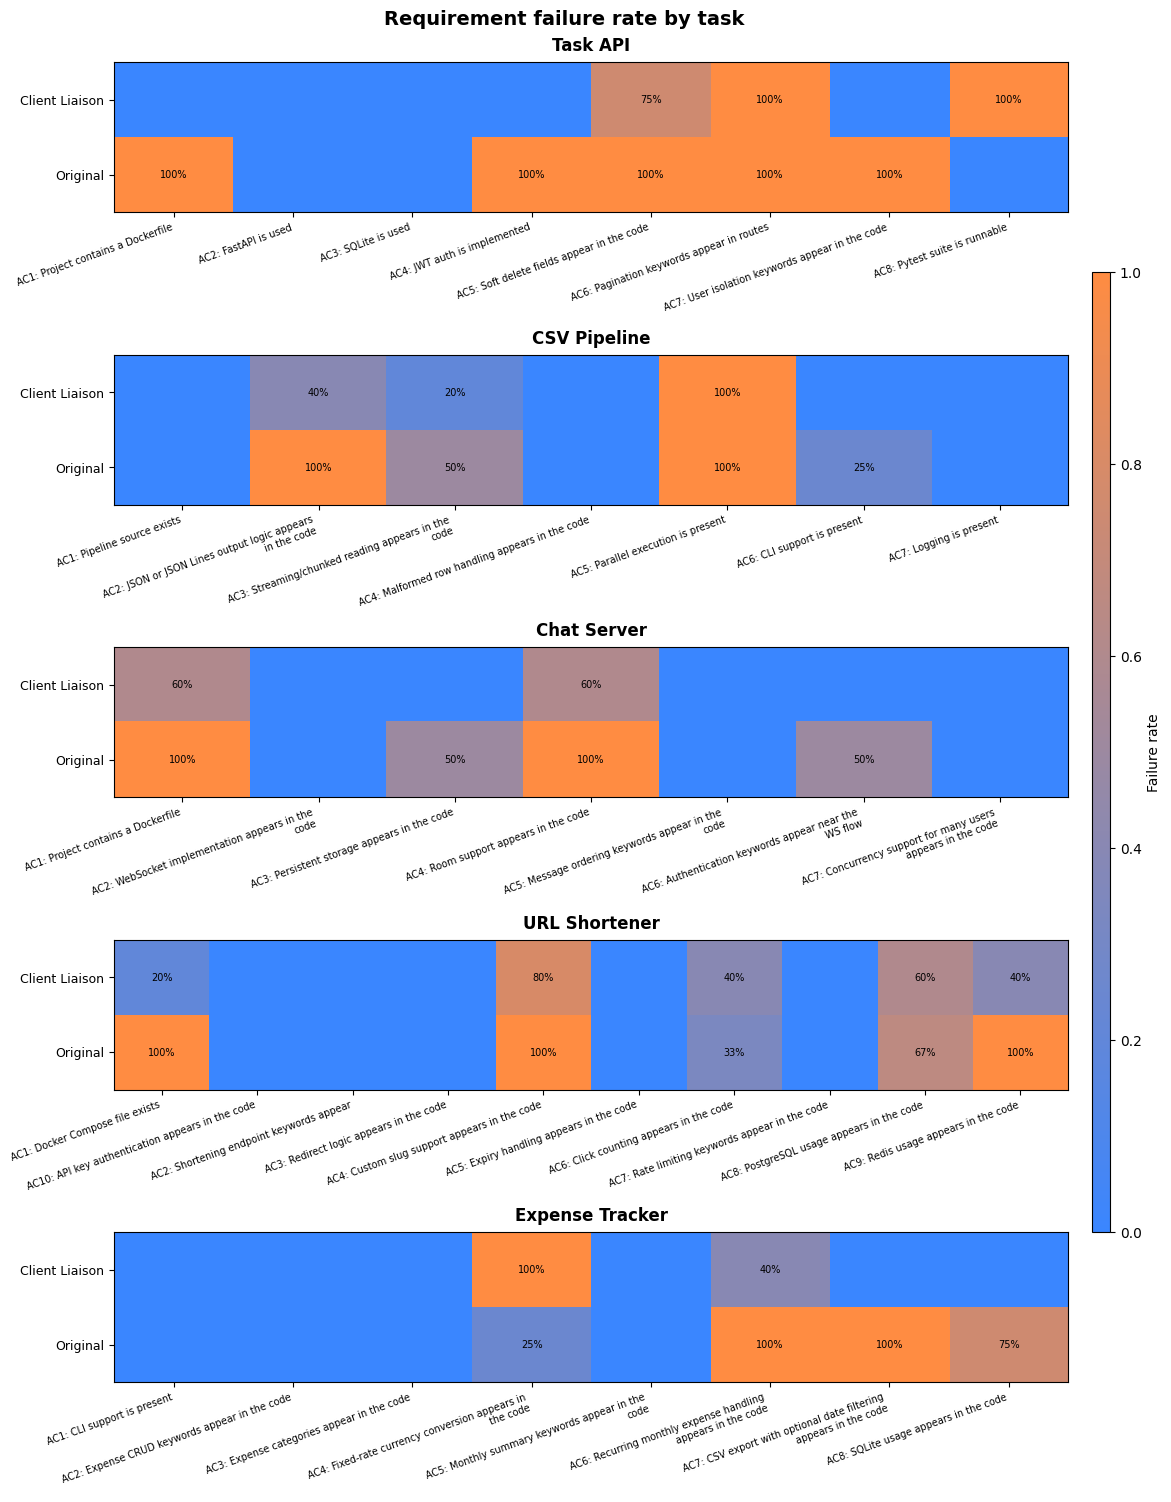

In [19]:
import json
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

RESULT_FILES = {
    'results_CL.json': Path(r'C:\Users\vasco\Downloads\ChatDev\results_CL.json'),
    'results_ablation.json': Path(r'C:\Users\vasco\Downloads\ChatDev\results_ablation.json'),
    'results_benchmark.json': Path(r'C:\Users\vasco\Downloads\ChatDev\results_benchmark.json'),
}
JSON_FILE_PRIORITY = {json_file: index for index, json_file in enumerate(RESULT_FILES)}

if 'thread_to_group' not in globals():
    raise RuntimeError('Run group mapping must be executed before this cell.')

CONSIDERED_THREAD_IDS = set(thread_to_group.keys())

def _condition_from_run_group(run_group: str | None) -> str | None:
    if not run_group:
        return None
    if run_group.startswith('client_liaison'):
        return 'Client Liaison'
    if run_group.startswith('original'):
        return 'Original'
    return None

def load_unique_benchmark_results(result_files: dict[str, Path]) -> pd.DataFrame:
    rows = []
    for json_file, path in result_files.items():
        if not path.exists():
            continue
        payload = json.loads(path.read_text(encoding='utf-8'))
        results = payload.get('results', payload if isinstance(payload, list) else [])
        for result in results:
            thread_id = result.get('thread_id')
            if not thread_id or thread_id not in CONSIDERED_THREAD_IDS:
                continue
            run_group = thread_to_group.get(thread_id)
            rows.append({
                'json_file': json_file,
                'json_file_priority': JSON_FILE_PRIORITY[json_file],
                'thread_id': thread_id,
                'run_group': run_group,
                'benchmark': result.get('benchmark'),
                'condition': _condition_from_run_group(run_group),
                'checks': result.get('checks', []),
            })

    raw_df = pd.DataFrame(rows)
    if raw_df.empty:
        print('No benchmark results matched the thread_groups filter.')
        return raw_df

    return (
        raw_df
        .sort_values(['thread_id', 'json_file_priority'])
        .drop_duplicates(subset=['thread_id'], keep='first')
        .drop(columns=['json_file_priority'])
        .reset_index(drop=True)
    )

def build_requirement_check_table(results_df: pd.DataFrame, include_quality_checks: bool = False) -> pd.DataFrame:
    rows = []
    if results_df.empty:
        return pd.DataFrame()
    for _, result in results_df.iterrows():
        for check in result.get('checks', []):
            check_id = check.get('check_id')
            if not include_quality_checks and check_id == 'NO_STUBS':
                continue
            if pd.to_numeric(check.get('weight', 1.0), errors='coerce') == 0:
                continue
            rows.append({
                'condition': result['condition'],
                'thread_id': result['thread_id'],
                'benchmark': result['benchmark'],
                'check_id': check_id,
                'requirement': check.get('description'),
                'passed': bool(check.get('passed')),
            })
    return pd.DataFrame(rows)

def _task_requirement_label(row: pd.Series) -> str:
    text = str(row.get('requirement', '')).strip()
    if len(text) > 42:
        split_at = text.rfind(' ', 0, 42)
        split_at = split_at if split_at > 18 else 42
        first = text[:split_at].strip()
        second = text[split_at:].strip()
        if len(second) > 42:
            second = second[:39].rstrip() + '...'
        text = f'{first}\n{second}'
    return f"{row.get('check_id')}: {text}"

def plot_failure_heatmaps_by_task(checks_df: pd.DataFrame, filename: str) -> None:
    if checks_df.empty:
        print('Skipping task failure heatmaps: no requirement check data.')
        return
    work = checks_df.copy()
    work['failed'] = ~work['passed']
    work['requirement_label'] = work.apply(_task_requirement_label, axis=1)
    benchmarks = [benchmark for benchmark in BENCHMARKS if benchmark in set(work['benchmark'].dropna())]
    if not benchmarks:
        print('Skipping task failure heatmaps: no benchmarks available.')
        return

    fig_height = max(3.0 * len(benchmarks), 3.5)
    fig, axes = plt.subplots(len(benchmarks), 1, figsize=(12, fig_height), squeeze=False)
    axes_flat = axes.flatten()
    cmap = LinearSegmentedColormap.from_list('failure_blue_orange', ['#3A86FF', '#FF8C42'])

    for ax, benchmark in zip(axes_flat, benchmarks):
        task_df = work[work['benchmark'] == benchmark]
        grouped = (
            task_df.groupby(['condition', 'requirement_label'], dropna=False)
            .agg(failures=('failed', 'sum'), evaluated=('thread_id', 'nunique'))
            .reset_index()
        )
        grouped['failure_rate'] = grouped['failures'] / grouped['evaluated']
        matrix = grouped.pivot(index='condition', columns='requirement_label', values='failure_rate').fillna(0)
        row_order = ['Client Liaison', 'Original']
        col_order = (
            task_df.groupby(['check_id', 'requirement_label'])['failed']
            .sum()
            .reset_index()
            .sort_values(['check_id'])['requirement_label']
        )
        matrix = matrix.reindex(index=row_order, columns=col_order).fillna(0)

        im = ax.imshow(matrix.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
        ax.set_title(BENCH_LABELS.get(benchmark, benchmark), fontsize=12, fontweight='bold', pad=8)
        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_xticklabels(matrix.columns, rotation=20, ha='right', fontsize=7)
        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(matrix.index, fontsize=9)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                cell_value = matrix.iat[i, j]
                if cell_value > 0:
                    ax.text(j, i, f'{cell_value:.0%}', ha='center', va='center', fontsize=7, color='black')

    fig.suptitle('Requirement failure rate by task', fontsize=14, fontweight='bold', y=0.995)
    fig.subplots_adjust(hspace=0.95, right=0.92, top=0.96, bottom=0.08)
    cbar_ax = fig.add_axes([0.94, 0.18, 0.015, 0.64])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Failure rate')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

benchmark_results_unique = load_unique_benchmark_results(RESULT_FILES)
requirement_checks_df = build_requirement_check_table(benchmark_results_unique)
plot_failure_heatmaps_by_task(requirement_checks_df, 'requirement_failures_by_task_heatmap.png')


## 9. Diagnostics


In [20]:
print("Feedback score columns:", list(feedback_df.columns))
print("Score names:", sorted(feedback_df["score_name"].dropna().unique().tolist()) if not feedback_df.empty else [])

if not feedback_df.empty:
    feedback_summary = (
        feedback_df
        .groupby("score_name", dropna=False)["score_value"]
        .agg(["count", "mean", "min", "max"])
        .sort_values("mean", ascending=False)
    )
    score_by_node = (
        feedback_df
        .groupby(["node_id", "score_name"], dropna=False)["score_value"]
        .agg(["count", "mean"])
        .reset_index()
    )
    display(feedback_summary)
    display(score_by_node.head(20))

all_opik_threads = set(traces_raw["thread_id"].dropna().unique())
mapped_client_liaison = {tid for tid, group in thread_to_group.items() if group.startswith("client")}
mapped_original = {tid for tid, group in thread_to_group.items() if group.startswith("original")}

print(f"Total Opik threads: {len(all_opik_threads)}")
print(f"Mapped Client Liaison threads: {len(mapped_client_liaison)}")
print(f"Mapped Original threads: {len(mapped_original)}")
print(f"Client Liaison threads found in Opik: {len(all_opik_threads & mapped_client_liaison)}")
print(f"Original threads found in Opik: {len(all_opik_threads & mapped_original)}")

unmapped_examples = [
    "092ab63d-3a82-4b5f-9d80-0e8f385a57c5",
    "9b228c5c-c275-4bc2-adf7-d26bc1441b87",
    "b184b195-2124-4f13-b5ad-c25669f95993",
    "b2b8f898-f3f6-42b3-92be-7e1b6643835e",
    "c98e0afa-94d3-40ed-8952-d180333f06d4",
    "dbed0c80-02de-4479-91d3-fdb6332e3382",
]

for thread_id in unmapped_examples:
    subset = traces_raw[traces_raw["thread_id"] == thread_id][["thread_id", "tags", "metadata.node_id"]].head(3)
    if not subset.empty:
        print(f"\nExample unmapped thread: {thread_id}")
        print(subset.to_string())


Feedback score columns: ['trace_id', 'thread_id', 'node_id', 'score_name', 'score_value', 'score_reason']
Score names: ['Handoff Quality', 'Responsiveness', 'Role Compliance', 'Score name', 'client_satisfaction', 'compile_success', 'dialogue_overhead', 'handoff_quality', 'input_responsiveness', 'latency_score', 'liaison_used', 'num_clarifications', 'output_valid_json', 'phase_coherence', 'phase_compliance', 'requirement_code_alignment', 'requirement_convergence', 'requirement_coverage', 'requirement_preservation', 'response_completeness', 'role_compliance', 'score 2', 'score 3', 'score1', 'stub_free_code', 'token_efficiency', 'total_tokens', 'total_trace_cost', 'trace_duration_seconds', 'trace_efficiency']


,count,mean,min,max
score_name,,,,
score1,1,7.000000,7.000,7.000
score 2,1,6.000000,6.000,6.000
score 3,1,6.000000,6.000,6.000
handoff_quality,935,5.965775,1.000,10.000
role_compliance,935,5.932620,1.000,10.000
input_responsiveness,942,5.915074,1.000,10.000
Handoff Quality,1586,5.881778,1.000,10.000
Role Compliance,1586,5.864439,1.000,10.000
Responsiveness,1583,5.821541,1.000,10.000


,node_id,score_name,count,mean
0,Chief Executive Officer,Handoff Quality,164,7.185976
1,Chief Executive Officer,Responsiveness,164,7.182927
2,Chief Executive Officer,Role Compliance,164,7.320122
3,Chief Executive Officer,Score name,2,4.800000
4,Chief Executive Officer,handoff_quality,66,7.318182
5,Chief Executive Officer,input_responsiveness,67,7.238806
6,Chief Executive Officer,requirement_preservation,1,5.000000
7,Chief Executive Officer,role_compliance,66,7.454545
8,Chief Executive Officer,total_trace_cost,6,0.000000
9,Chief Executive Officer,trace_efficiency,1,3.000000


Total Opik threads: 223
Mapped Client Liaison threads: 25
Mapped Original threads: 25
Client Liaison threads found in Opik: 25
Original threads found in Opik: 25

Example unmapped thread: 092ab63d-3a82-4b5f-9d80-0e8f385a57c5
                                thread_id                      tags metadata.node_id
158  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]           Tester
159  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]    Code Reviewer
160  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]       Programmer

Example unmapped thread: 9b228c5c-c275-4bc2-adf7-d26bc1441b87
                                thread_id                         tags metadata.node_id
164  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]           Tester
165  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]    Code Reviewer
166  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]       Programmer

Example unmapped th